<a href="https://colab.research.google.com/github/devarahaasan/forest-cover-classification/blob/main/project3c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classification

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

file_path = r"/content/drive/MyDrive/cleaned_data2.csv"
df= pd.read_csv(file_path)
df.head()

,Elevation_Vertical_Hydro,Elevation,Road_Fire_Total,Soil_Type,Horizontal_Distance_To_Fire_Points,Hydro_Fire_Total,Hydro_Road_Total,Horizontal_Distance_To_Roadways,Hydro_Road_Diff,Distance_to_Hydrology,Cover_Type
0,-1.273107,-1.422686,0.155974,0.616693,1.835567,1.811889,-1.600904,-1.661258,-1.708151,0.199646,0
1,-1.273107,-1.452980,0.092891,0.616693,1.804918,1.756002,-1.695956,-1.732357,-1.753091,-0.036943,0
2,-0.542612,-0.372506,1.066701,-1.297641,1.745890,1.729176,-0.066318,-0.079292,-0.092748,0.286665,4
3,-0.905305,-0.468436,1.066701,0.821840,1.796972,1.764944,-0.132741,-0.132617,-0.131615,0.252805,4
4,-1.273107,-1.427735,0.074038,0.616693,1.774836,1.693408,-1.729168,-1.731765,-1.716653,-0.373956,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 11 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation_Vertical_Hydro            145890 non-null  float64
 1   Elevation                           145890 non-null  float64
 2   Road_Fire_Total                     145890 non-null  float64
 3   Soil_Type                           145890 non-null  float64
 4   Horizontal_Distance_To_Fire_Points  145890 non-null  float64
 5   Hydro_Fire_Total                    145890 non-null  float64
 6   Hydro_Road_Total                    145890 non-null  float64
 7   Horizontal_Distance_To_Roadways     145890 non-null  float64
 8   Hydro_Road_Diff                     145890 non-null  float64
 9   Distance_to_Hydrology               145890 non-null  float64
 10  Cover_Type                          145890 non-null  int64  
dtypes: float64(10), int64(1)
m

In [4]:
df.isnull().sum()

,0
Elevation_Vertical_Hydro,0
Elevation,0
Road_Fire_Total,0
Soil_Type,0
Horizontal_Distance_To_Fire_Points,0
Hydro_Fire_Total,0
Hydro_Road_Total,0
Horizontal_Distance_To_Roadways,0
Hydro_Road_Diff,0
Distance_to_Hydrology,0


In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

Checking if the target classes are balanced

In [8]:
df['Cover_Type'].value_counts()

,count
Cover_Type,
4,103070
6,31110
0,3069
3,2160
5,2160
2,2160
1,2160


In [9]:
df.columns

Index(['Elevation_Vertical_Hydro', 'Elevation', 'Road_Fire_Total', 'Soil_Type',
       'Horizontal_Distance_To_Fire_Points', 'Hydro_Fire_Total',
       'Hydro_Road_Total', 'Horizontal_Distance_To_Roadways',
       'Hydro_Road_Diff', 'Distance_to_Hydrology', 'Cover_Type'],
      dtype='object')

Handling class imbalance

In [10]:
from imblearn.over_sampling import SMOTE

X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)
print(pd.Series(y_resampled).value_counts())


Cover_Type
0    103070
4    103070
6    103070
3    103070
5    103070
2    103070
1    103070
Name: count, dtype: int64


Model building

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

RandomForestClassifier

In [12]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

rf_model.fit(X_train_scaled, y_train)

print("Model Training Completed!")

Model Training Completed!


In [13]:
y_pred = rf_model.predict(X_test_scaled)

In [14]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


y_train_pred = rf_model.predict(X_train_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

print(f" Testing Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")

#(Precision, Recall, F1-score)
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Training Accuracy: 100.00%
 Testing Accuracy Score: 0.99

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20665
           1       1.00      1.00      1.00     20549
           2       1.00      1.00      1.00     20681
           3       1.00      1.00      1.00     20601
           4       0.99      0.98      0.99     20646
           5       1.00      1.00      1.00     20600
           6       0.98      0.99      0.99     20556

    accuracy                           0.99    144298
   macro avg       0.99      0.99      0.99    144298
weighted avg       0.99      0.99      0.99    144298



Cross Validation for RandomForestClassifier

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5)

print("Cross-val scores:", scores.mean())

Cross-val scores: 0.9933211134467292


In [ ]:
print(X_train.columns.tolist())

['Elevation_Vertical_Hydro', 'Elevation', 'Road_Fire_Total', 'Soil_Type', 'Horizontal_Distance_To_Fire_Points', 'Hydro_Fire_Total', 'Hydro_Road_Total', 'Horizontal_Distance_To_Roadways', 'Hydro_Road_Diff', 'Distance_to_Hydrology']


XGBoost

In [20]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report


X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=7,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)


xgb_model.fit(X_train_scaled, y_train_resampled)


y_pred = xgb_model.predict(X_test_scaled)

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final Accuracy: 0.8506751662211255

Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.96      0.57       614
           1       0.93      0.94      0.93       432
           2       0.68      0.80      0.74       432
           3       0.84      0.98      0.91       432
           4       0.96      0.84      0.90     20614
           5       0.75      0.77      0.76       432
           6       0.69      0.86      0.77      6222

    accuracy                           0.85     29178
   macro avg       0.75      0.88      0.80     29178
weighted avg       0.88      0.85      0.86     29178



 Hyperparameter Tuning for XGBoost using RandomizedSearchCV

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint


param_dist = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': [6, 8, 10, 12],
    'subsample': uniform(0.7, 0.3)
}


random_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(objective="multi:softprob", num_class=7, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=42
)


random_search.fit(X_train_scaled, y_train_resampled)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'learning_rate': np.float64(0.16703519227860275), 'max_depth': 10, 'n_estimators': 463, 'subsample': np.float64(0.8542703315240834)}
Best Score: 0.9932015707132239


Final Test Accuracy: 0.967955308794297

Detailed Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92       614
           1       0.95      0.96      0.95       432
           2       0.84      0.85      0.85       432
           3       0.91      0.98      0.94       432
           4       0.99      0.98      0.98     20614
           5       0.83      0.84      0.84       432
           6       0.94      0.95      0.95      6222

    accuracy                           0.97     29178
   macro avg       0.91      0.93      0.92     29178
weighted avg       0.97      0.97      0.97     29178



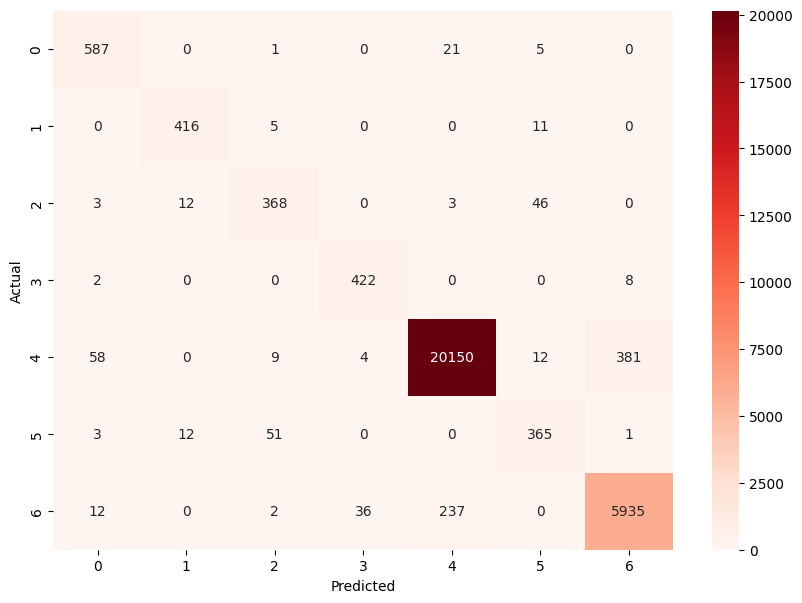

In [24]:
# Best parameters and accuracy for XGBoost

best_xgb = random_search.best_estimator_
y_pred_final = best_xgb.predict(X_test_scaled)



from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Final Test Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nDetailed Report:\n", classification_report(y_test, y_pred_final))




cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [25]:
import pickle

In [26]:
with open('forest_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

print("data saved succesfully")

data saved succesfully


In [27]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Scaler data saved succesfully")

Scaler data saved succesfully


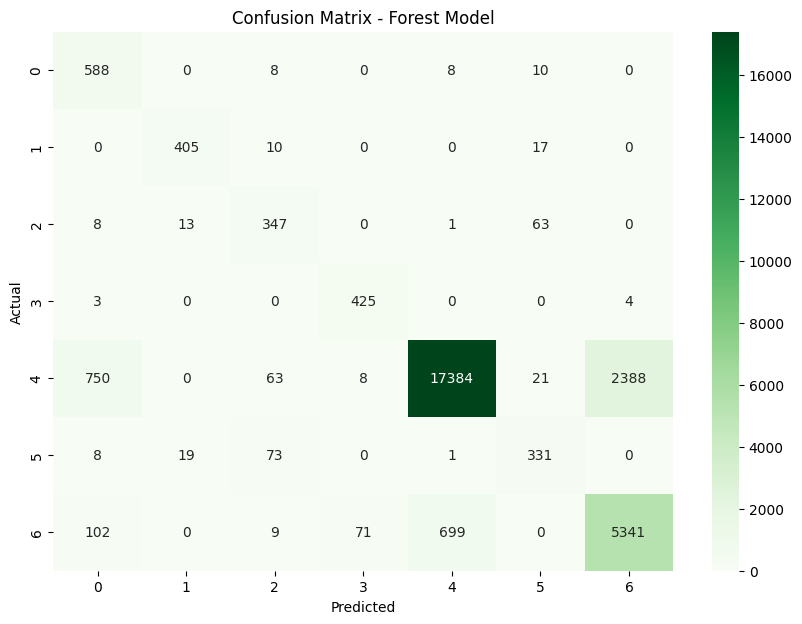

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')


plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Forest Model')
plt.show()

class   :  Cover Type Name:

0= Spruce/Fir

1=Lodgepole Pine

2=Ponderosa Pine

3=Cottonwood/Willow

4=Aspen

5=Douglas-fir

6=Krummholz

In [29]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 67.5 MB/s eta 0:00:00
--2026-03-17 11:28:49--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-03-17 11:28:49--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-17T12%3A23%3A04Z&rscd=attachment%3B+filename%3Dclou

In [30]:
!pip install streamlit-option-menu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 7.8 MB/s eta 0:00:00


In [31]:

%%writefile project3.py

import streamlit as st
import pickle
import numpy as np


model = pickle.load(open('forest_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

st.markdown(
    """
    <style>
    /* 1.(Main Background) */
    .stApp {
        background-color: #000000;
    }

    /* 2.(Text Color) */
    .stApp h1, .stApp h2, .stApp h3, .stApp p, .stApp label, .stApp span {
        color: #ffffff !important;
    }

    /* 3.(Input Boxes) */
    .stNumberInput input, .stSelectbox div {
        background-color: #333333 !important;
        color: white !important;
        border: 1px solid #555555 !important;
    }

    /* 4.(Button Style) */
    div.stButton > button:first-child {
        background-color: #2e7d32; /*  */
        color: white;
        border-radius: 8px;
        width: 100%;
        border: none;
    }

    div.stButton > button:hover {
        background-color: #1b5e20; /*  */
        color: white;
    }
    </style>
    """,
    unsafe_allow_html=True
)


st.title("Forest Cover Type Prediction 🌲")


col1, col2 = st.columns(2)

with col1:
    elevation = st.number_input("Elevation", value=0.0)
    hydro_dist = st.number_input("Distance to Hydrology", value=0.0)
    road_dist = st.number_input("Distance to Roadways", value=0.0)
    fire_dist = st.number_input("Distance to Fire Points", value=0.0)

with col2:
    v_hydro = st.number_input("Elevation Vertical Hydro", value=0.0)
    road_fire_total = st.number_input("Road Fire Total", value=0.0)
    hydro_fire_total = st.number_input("Hydro Fire Total", value=0.0)
    hydro_road_total = st.number_input("Hydro Road Total", value=0.0)
    hydro_road_diff = st.number_input("Hydro Road Diff", value=0.0)


st.write("---")


soil_names = {
    1: "Cathedral family - Rock outcrop complex", 2: "Vanet - Ratake families complex",
    3: "Haploborolls - Rock outcrop complex", 4: "Ratake family - Rock outcrop complex",
    5: "Vanet family - Rock outcrop complex", 6: "Vanet - Wetmore families",
    7: "Gothic family", 8: "Supervisor - Limber families", 9: "Troutville family",
    10: "Bullwark - Catamount families", 11: "Bullwark - Catamount families - Rock land",
    12: "Legault family", 20: "Typic Cryaquepts", 29: "Leighcan family", 40: "Moran family"

}

soil_id = st.selectbox("Select Soil Type", options=list(soil_names.keys()),
                       format_func=lambda x: f"Soil Type {x}: {soil_names[x]}")

st.write(f"Selected Soil ID: {soil_id}")


target_names = {0: 'Spruce/Fir', 1: 'Lodgepole Pine', 2: 'Ponderosa Pine',
                3: 'Cottonwood/Willow', 4: 'Aspen', 5: 'Douglas-fir', 6: 'Krummholz'}


if st.button("Predict Cover Type"):

    features = np.array([[v_hydro, elevation, road_fire_total, soil_id,
                          fire_dist, hydro_fire_total, hydro_road_total,
                          road_dist, hydro_road_diff, hydro_dist]])


    scaled_features = scaler.transform(features)


    prediction = model.predict(scaled_features)

    final_result = target_names[prediction[0]]

    st.success(f"Predicted Cover Type: **{final_result}**")

Writing project3.py


In [32]:
!streamlit run /content/project3.py &>/content/logs.txt &

In [33]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://indianapolis-due-made-systems.trycloudflare.com
